# The `NetCDF` class — anatomy & reference

A hands-on tour of pyramids' [`NetCDF`](https://serapeum-org.github.io/pyramids/) class: what a NetCDF
file *is* to pyramids, how the class is laid out, and the methods you reach for day to day — each shown
on real sample data so you can copy the cells straight into your own work.

`NetCDF` is a GDAL-multidimensional-backed subclass of `Dataset`. A single `.nc` file can hold many
variables, their dimensions and coordinates, per-variable and file-wide (*global*) attributes, and — in
the NetCDF-4 format — nested **groups**. pyramids models this with **two roles for one class**:

- a **container** — the file as a whole: it lists variables, dimensions, groups and global metadata;
- a **variable subset** — one variable pinned out of the container (via `get_variable`), which then
  behaves like an ordinary georeferenced raster (it has a CRS, a geotransform, an array, no-data, and the
  full `Dataset` operation surface: `crop`, `reduce`, `to_crs`, `plot`, ...).

By the end you will be able to open a file, inspect its structure, pull out a variable, read its array
(eager or lazy), read its metadata and coordinates, walk NetCDF-4 groups, run container operations, and
know which method to call for what.

## The anatomy at a glance

```mermaid
graph TD
    F["NetCDF container<br/>(NetCDF.read_file)"] --> G["global attributes<br/>(title, institution, ...)"]
    F --> D["dimensions<br/>(lon, lat, time, ...)"]
    F --> V["variables<br/>(variable_names)"]
    F --> GR["groups (NetCDF-4)<br/>(group_names / get_group)"]
    V --> S["variable subset<br/>(get_variable → NetCDF)"]
    S --> A["data array<br/>(read_array)"]
    S --> C["coordinates & geo<br/>(lon/lat/x/y, geotransform, epsg)"]
    S --> PA["per-variable attributes<br/>(scale_factor, units, ...)"]
```

Read it top-down: a **container** exposes global attributes, dimensions, variables and groups; calling
`get_variable` descends into a single variable, which carries its own array, coordinates and attributes.

## Setup

Imports and the one notebook-relative data path. The sample files ship in the repo's
`examples/data/netcdf/` folder; the path is written relative to *this notebook's* directory. We keep the
imports and paths here so the teaching cells below stay about `NetCDF`, not plumbing.

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd

from pyramids.netcdf import NetCDF

DATA = Path('../../../examples/data/netcdf')
SAMPLES = DATA / 'samples'

# A CF sea-surface-temperature file (multi-variable, has a time axis): our main example.
MAIN = SAMPLES / 'cf__7v__1d3-2d3-3d1__y-asc.nc'
# A NetCDF-4 file organised into nested groups.
GROUPS = SAMPLES / 'none__35v__1d35__groups-nc4.nc'
# A file with packed (scale_factor / add_offset) variables.
PACKED = DATA / 'coards__4v__1d2-2d2__scaleoffset__y-asc.nc'

## 1. Open a file → a container

`NetCDF.read_file(path)` opens a `.nc` file and returns a **container**. Displaying it gives a summary of
the file: its variables, dimensions and shape.

| argument | meaning | typical value |
|---|---|---|
| `path` | path to the `.nc` file | `Path(...)` or `str` |
| `read_only` | open read-only (default) or writable | `True` |
| `open_as_multi_dimensional` | use GDAL's multidim API (default) | `True` |

In [2]:
nc = NetCDF.read_file(MAIN)
nc

Driver: netCDF/Network Common Data Format
Files: ../../../examples/data/netcdf/samples/cf__7v__1d3-2d3-3d1__y-asc.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

The summary above is the *container* view — it describes the whole file. Nothing is loaded into memory
yet; pyramids reads arrays only when you ask for them.

## 2. The two roles: container vs variable subset

One class, two roles. Knowing which one you hold tells you which methods make sense.

| role | what it is | how you get it | exposes |
|---|---|---|---|
| **container** | the whole file | `NetCDF.read_file(path)` | `variable_names`, `dimension_sizes`, `group_names`, `global_attributes`, `get_variable` |
| **variable subset** | one pinned variable | `container.get_variable(name)` | a raster surface: `read_array`, `geotransform`, `epsg`, `no_data_value`, `crop`, `reduce`, `plot` |

Container-wide reads/ops (`read_array`, `crop`, `reduce`) auto-route to the named variable when you pass
`variable=`, or you pin one first with `get_variable`.

## 3. Variables — what the container holds

`variable_names` lists every variable in the file. `variables` is a lazy mapping (`name → NetCDF
subset`) that materialises a subset only on first access.

In [3]:
nc.variable_names

['lon_bnds', 'lat_bnds', 'time_bnds', 'tos']

Here `tos` is the data variable (sea-surface temperature); `lon_bnds` / `lat_bnds` / `time_bnds` are CF
*bounds* variables describing cell edges. `variables` lets you index them lazily:

In [4]:
type(nc.variables), nc.variables['tos']

(pyramids.netcdf.netcdf._LazyVariableDict,
 Files: ../../../examples/data/netcdf/samples/cf__7v__1d3-2d3-3d1__y-asc.nc
 Size is 180, 170
 Origin = (0.000000000000000,90.000000000000000)
 Pixel Size = (2.000000000000000,-1.000000000000000)
 Metadata:
   standard_name=sea_surface_temperature
   long_name=Sea Surface Temperature
   cell_methods=time: mean (interval: 30 minutes)
   original_name=sosstsst
   original_units=degC
   history= At   16:37:23 on 01/11/2005: CMOR altered the data in the following ways: added 2.73150E+02 to yield output units;  Cyclical dimension was output starting at a different lon;
 Corner Coordinates:
 Upper Left  (   0.0000000,  90.0000000) 
 Lower Left  (   0.0000000, -80.0000000) 
 Upper Right (     360.000,      90.000) 
 Lower Right (     360.000,     -80.000) 
 Center      ( 180.0000000,   5.0000000) 
 Band 1 Block=180x1 Type=Float32, ColorInterp=Undefined
   NoData Value=1e+20
   Unit Type: K
   Metadata:
     DIM_time_INDEX=0
     DIM_time_VALUE=15
   

## 4. `get_variable` → a variable subset

`get_variable(name)` pins one variable and returns a `NetCDF` that behaves like a georeferenced raster.
For files where the lat/lon axes are not the trailing dimensions, pass `x_dim=` / `y_dim=` to say which
axes are geographic.

In [5]:
tos = nc.get_variable('tos')
tos

Files: ../../../examples/data/netcdf/samples/cf__7v__1d3-2d3-3d1__y-asc.nc
Size is 180, 170
Origin = (0.000000000000000,90.000000000000000)
Pixel Size = (2.000000000000000,-1.000000000000000)
Metadata:
  standard_name=sea_surface_temperature
  long_name=Sea Surface Temperature
  cell_methods=time: mean (interval: 30 minutes)
  original_name=sosstsst
  original_units=degC
  history= At   16:37:23 on 01/11/2005: CMOR altered the data in the following ways: added 2.73150E+02 to yield output units;  Cyclical dimension was output starting at a different lon;
Corner Coordinates:
Upper Left  (   0.0000000,  90.0000000) 
Lower Left  (   0.0000000, -80.0000000) 
Upper Right (     360.000,      90.000) 
Lower Right (     360.000,     -80.000) 
Center      ( 180.0000000,   5.0000000) 
Band 1 Block=180x1 Type=Float32, ColorInterp=Undefined
  NoData Value=1e+20
  Unit Type: K
  Metadata:
    DIM_time_INDEX=0
    DIM_time_VALUE=15
    DIM_time_UNIT=days since 2001-1-1
Band 2 Block=180x1 Type=Float32

The subset now reports *its* shape, CRS and geotransform — it is a raster you can read, crop, reproject
or plot.

## 5. Dimensions

`dimension_sizes` maps each dimension name to its length; `dimension_names` lists them in order. This is
the coordinate skeleton every variable is defined on.

In [6]:
pd.DataFrame(
    sorted(nc.dimension_sizes.items()), columns=['dimension', 'size']
).set_index('dimension')

,size
dimension,
bnds,2
lat,170
lon,180
time,24


## 6. Metadata — global attributes and the full summary

`global_attributes` returns the file-wide (CF *global*) attributes as a dict. `get_all_metadata()`
returns a `NetCDFMetadata` object whose printout summarises the dimensions and, per variable, its
dims / shape / dtype / unit / scale-offset.

In [7]:
pd.Series(nc.global_attributes, name='value').to_frame()

,value
title,IPSL model output prepared for IPCC Fourth As...
institution,"IPSL (Institut Pierre Simon Laplace, Paris, Fr..."
source,IPSL-CM4_v1 (2003) : atmosphere : LMDZ (IPSL-C...
contact,"Sebastien Denvil, sebastien.denvil@ipsl.jussie..."
project_id,IPCC Fourth Assessment
table_id,Table O1 (13 November 2004)
experiment_id,SRES A2 experiment
realization,1
cmor_version,0.96
Conventions,CF-1.0


In [8]:
print(nc.get_all_metadata())

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    bnds                 size=2
    lat                  size=170
    lon                  size=180
    time                 size=24
  Variables (7):
    lat dims=('/lat',) shape=(170,) dtype=float64 unit='degrees_north'
    lat_bnds dims=('/lat', '/bnds') shape=(170, 2) dtype=float64
    lon dims=('/lon',) shape=(180,) dtype=float64 unit='degrees_east'
    lon_bnds dims=('/lon', '/bnds') shape=(180, 2) dtype=float64
    time dims=('/time',) shape=(24,) dtype=float64 unit='days since 2001-1-1'
    time_bnds dims=('/time', '/bnds') shape=(24, 2) dtype=float64
    tos dims=('/time', '/lat', '/lon') shape=(24, 170, 180) dtype=float32 unit='K'
  Global attributes: title, institution, source, contact, project_id, ... (13 total)


`global_attributes` is the quick key/value view; `get_all_metadata()` is the structured, per-variable
report you skim to understand an unfamiliar file.

## 7. Coordinates & georeferencing

Because a variable subset is a raster, it exposes the geospatial surface inherited from `Dataset`: the
CRS (`epsg`), the affine `geotransform`, the axis coordinate arrays (`lon`/`lat` or `x`/`y`), the
`no_data_value`, and the corner (`top_left_corner`).

In [9]:
pd.Series(
    {
        'epsg': tos.epsg,
        'geotransform': tuple(round(float(g), 3) for g in tos.geotransform),
        'top_left_corner': tos.top_left_corner,
        'no_data_value[0]': tos.no_data_value[0],
        'lon range': (float(tos.lon.min()), float(tos.lon.max())),
        'lat range': (float(tos.lat.min()), float(tos.lat.max())),
    },
    name='value',
).to_frame()

,value
epsg,4326
geotransform,"(0.0, 2.0, 0.0, 90.0, 0.0, -1.0)"
top_left_corner,"(0.0, 90.0)"
no_data_value[0],100000002004087734272.0
lon range,"(1.0, 359.0)"
lat range,"(-79.5, 89.5)"


Note the longitudes run 0–360 here — a common convention for global CF grids. `wrap_longitude()`
re-frames them to −180…180 when you need to line up with −180…180 geometries or basemaps.

## 8. Reading arrays

`read_array` pulls the values into NumPy (eager by default). On a *container* you must say which
variable; on a *subset* the variable is already pinned. Key parameters:

| argument | meaning |
|---|---|
| `variable` | which variable (container only; a subset ignores it) |
| `window` | `[col_off, row_off, cols, rows]` sub-window (eager path) |
| `bbox` / `epsg` | read a bounding box in a given CRS instead of a pixel window |
| `unpack` | apply CF `scale_factor` / `add_offset` → real units |
| `masked` | return a `MaskedArray` with no-data cells masked |
| `chunks` | return a lazy `dask.array` instead of NumPy (needs the `[lazy]` extra) |

`tos` is 3-D — `(time, lat, lon)`.

In [10]:
arr = tos.read_array()
arr.shape

(24, 170, 180)

Read one time step as a **masked array** — the ocean/land no-data cells come back masked.

In [11]:
masked = tos.read_array(masked=True)
(type(masked).__name__, int(masked[0].count()))

('MaskedArray', 21090)

Now **view the variable with the class's own `plot()`**. Plotting in pyramids goes through [cleopatra](https://github.com/serapeum-org/cleopatra) — there's no hand-rolled matplotlib. For a >2-D variable `plot()` auto-selects a 2-D slice and returns a glyph whose matplotlib handles (`glyph.fig` / `glyph.ax` / `glyph.im`) you can tweak.

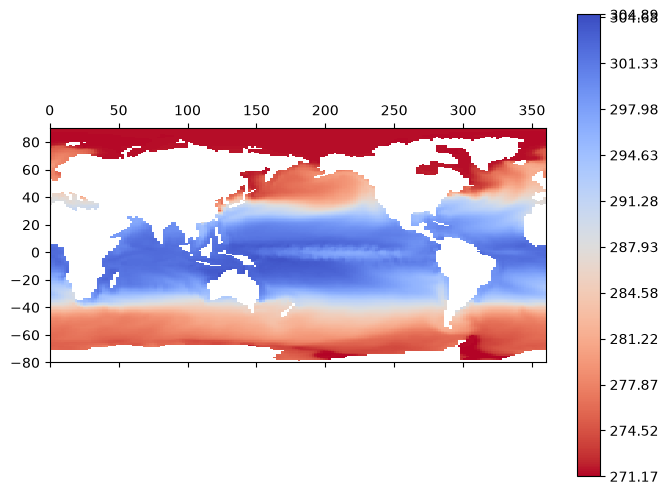

In [12]:
glyph = tos.plot()

That is the variable on its native 0–360 grid. The **Plotting** section below customises this — wrapping to −180…180 and overlaying a coastline for geographic context.

### Windowed reads

Pass `window=[col_off, row_off, cols, rows]` to read only a sub-block — handy for large files. The
spatial dims shrink; the time axis is untouched.

In [13]:
tos.read_array(window=[0, 0, 60, 40]).shape

(24, 40, 60)

## 9. Packed variables — `unpack`

Many NetCDF files store integers plus CF `scale_factor` / `add_offset` to save space. `read_array` reads
the raw stored values by default; `unpack=True` applies `real = raw * scale + offset`.

In [14]:
packed = NetCDF.read_file(PACKED)
z = packed.get_variable('z')
raw = z.read_array()
real = z.read_array(unpack=True)
pd.Series(
    {
        'raw mean (stored)': float(np.nanmean(raw)),
        'unpacked mean (real units)': float(np.nanmean(real)),
    },
    name='value',
).to_frame()

,value
raw mean (stored),0.0
unpacked mean (real units),1.5


## 10. Plotting

`NetCDF.plot()` delegates to [cleopatra](https://github.com/serapeum-org/cleopatra) and returns a glyph
whose matplotlib handles (`glyph.fig` / `glyph.ax` / `glyph.im`) you can tweak, and which **carries the data's CRS** — so `add_features` defaults its `crs` to the glyph's and needs no explicit `crs=`. We wrap longitudes to
−180…180 so the grid lines up with the coastline, plot in the data's own lon/lat CRS, then overlay the
Natural Earth coastline for geographic context.

<Axes: >

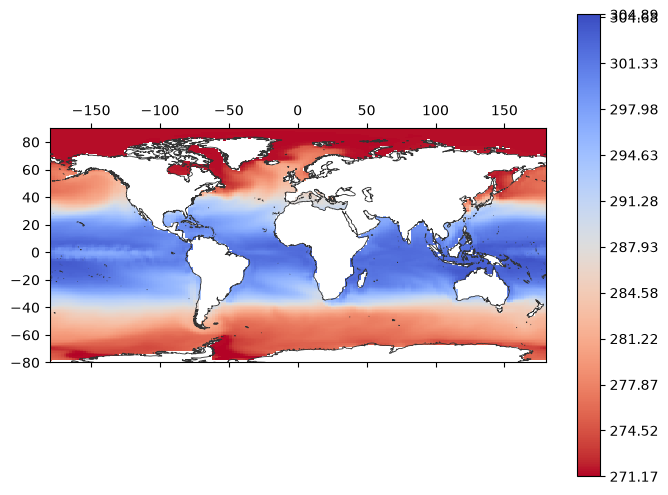

In [15]:
field = nc.get_variable('tos').wrap_longitude()
glyph = field.plot()
# the glyph already carries its CRS from plot(), so add_features defaults to it
glyph.add_features("coastline", "50m", zorder=5)

`add_features(layer, resolution)` takes the Natural Earth **layer** first — one of `coastline`, `borders`, `rivers`, `land`, `ocean`, `lakes` — and its **resolution** second: `110m` (coarse, the default), `50m` (medium, used here), or `10m` (fine). We omit `crs` because the glyph already carries it.

## 11. Time

CF files carry a time axis. `get_time_values()` returns the raw time-coordinate values (in the file's
time units); `time_stamp` exposes parsed timestamps when available.

In [16]:
times = nc.get_time_values()
times[:5]

array([ 15.,  45.,  75., 105., 135.])

## 12. Groups (NetCDF-4)

NetCDF-4 files can nest variables inside **groups**. `group_names` lists them; `get_group(name)` returns
that group as its own `NetCDF` container you can inspect the same way.

In [17]:
grouped = NetCDF.read_file(GROUPS)
grouped.group_names[:5]

['mozaic_flight_2012030403540535_ascent',
 'mozaic_flight_2012030321335035_descent',
 'mozaic_flight_2012030403540535_descent',
 'mozaic_flight_2012030412545335_ascent',
 'mozaic_flight_2012030419144751_ascent']

In [18]:
sub = grouped.get_group(grouped.group_names[0])
sub.variable_names[:8]

['air_press', 'CO', 'O3', 'altitude']

Each group is a self-contained container — same `variable_names` / `get_variable` / metadata surface as
the top level.

## 13. Container operations

Because a subset is a `Dataset`, the spatial/temporal operations work on netCDF too. `reduce` collapses a
dimension with an aggregation; `crop`, `to_crs`, `resample` and `sel` are also available (see the
quick-reference diagram below). Here we collapse the 24-step time axis to its mean — the `time` dimension disappears.

In [19]:
time_mean = nc.reduce('time', how='mean')
dict(time_mean.dimension_sizes)

/tmp/ipykernel_3594/2515305529.py:1: UserWarning: reduce() dropped auxiliary variable(s) ['time_bnds'] that span the reduced dimension 'time'; carrying them unchanged would leave an inconsistent 'time' length in the result.
  time_mean = nc.reduce('time', how='mean')


{'bnds': 2, 'lat': 170, 'lon': 180, 'x': 180, 'y': 170}

## 14. Export / interop

Write back to a `.nc` file with `to_file`, or emit a [kerchunk](https://fsspec.github.io/kerchunk/)
reference (`to_kerchunk`) so the file can be read lazily as a virtual Zarr store. Here we round-trip the
container to a temporary file.

In [20]:
out = Path(tempfile.mkdtemp()) / 'roundtrip.nc'
nc.to_file(out)
out.name, out.exists()

('roundtrip.nc', True)

## Methods & properties — quick reference

The API surface you will use most, grouped by role. **Container** members describe the file, **subset**
members act on one variable's raster, and **shared** members work on either level. The diagram shows how
you move between the two forms a `NetCDF` takes.


```mermaid
flowchart TB
    F[(".nc file · bytes · many files")]
    F -->|"read_file · from_bytes · open_mfdataset"| C

    subgraph C["NetCDF — container (describes the file)"]
        direction TB
        c1["variable_names · variables"]
        c2["dimension_sizes · dimension_names"]
        c3["global_attributes · get_all_metadata · meta_data"]
        c4["group_names · get_group"]
        c5["get_time_values · time_stamp"]
        c6["to_kerchunk"]
    end

    subgraph S["NetCDF — variable subset (one variable as a raster)"]
        direction TB
        s1["epsg · geotransform"]
        s2["lon / lat / x / y"]
        s3["no_data_value · wrap_longitude"]
    end

    subgraph B["shared — work on either level"]
        direction TB
        b1["read_array · crop · reduce"]
        b2["to_crs · resample · sel"]
        b3["plot · to_file · close"]
    end

    C -->|"get_variable · variables[name]"| S
    S -->|plot| G(["cleopatra glyph"])
```


## Takeaway

- `NetCDF.read_file` gives you a **container**; `get_variable` descends to a **variable subset** that is a
  full georeferenced raster.
- Inspect structure with `variable_names`, `dimension_sizes`, `global_attributes` / `get_all_metadata`,
  and `group_names` / `get_group` for NetCDF-4 groups.
- Read data with `read_array` — eager NumPy by default; `unpack=` for packed variables, `masked=` for a
  masked array, `window=` / `bbox=` for sub-reads, `chunks=` for lazy dask.
- Everything a `Dataset` can do (`crop`, `reduce`, `to_crs`, `resample`, `plot`, `to_file`) works on a
  netCDF variable too.

Next: the `explore/` notebooks walk real CF, COARDS, packed, curvilinear, staggered, grouped and UGRID
files end to end; `dask-lazy-netcdf.ipynb` covers lazy reads at scale.